In [ ]:
!pip install --upgrade keras
!pip install --upgrade keras-cv
!pip install --upgrade keras-hub
!pip install tensorflow
!pip install pandas
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 13.6 MB/s eta 0:00:00
  Attempting uninstall: keras
    Found existing installation: keras 3.8.0
    Uninstalling keras-3.8.0:
      Successfully uninstalled keras-3.8.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 792.1/792.1 kB 9.4 MB/s eta 0:00:00
  Attempting uninstall: keras-hub
    Found existing installation: keras-hub 0.18.1
    Uninstalling keras-hub-0.18.1:
      Successfully uninstalled keras-hub-0.18.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
keras-nlp 0.18.1 requires keras-hub==0.18.1, but you have keras-hub 0.20.0 which is incompatible.


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28)
Original data:  [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
After one-hot encoding:  [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 112s 70ms/step - accuracy: 0.8076 - loss: 0.6428 - val_accuracy: 0.9837 - val_loss: 0.0628
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 107s 68ms/step - accuracy: 0.9841 - loss: 0.0595 - val_accuracy: 0.9847 - val_loss: 0.0507
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 108s 69ms/step - accuracy: 0.9900 - loss: 0.0351 - val_accuracy: 0.9877 - val_loss: 0.0435
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 141s 69ms/step - accuracy: 0.9944 - loss: 0.0210 - val_accuracy: 0.9875 - val_loss: 0.0426
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 143s 69ms/step - accuracy: 0.9963 - loss: 0.0141 - val_accuracy: 0.9882 - val_loss: 0.0407
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 140s 68ms/step - accuracy: 0.9978 - loss: 0.0095 - val_accuracy: 0.9893 - val_loss: 0.0379
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 141s 68ms/step - accuracy: 0.9987 - loss: 0.0061 - val_accuracy: 0.9883 - val_loss: 0.0415
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 151s 74ms/step - accuracy: 

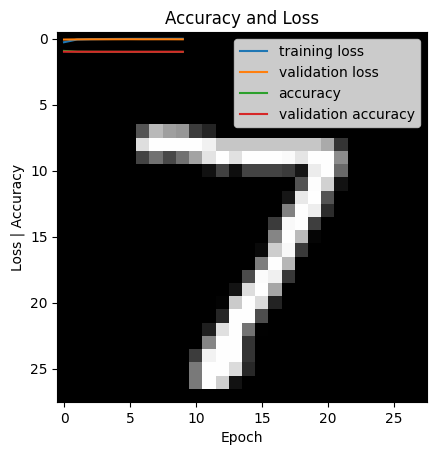

In [ ]:
#khai báo thiw viện
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Flatten
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from keras import utils
from keras.datasets import mnist

# Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_val, y_val = x_train[50000:60000, :], y_train[50000:60000]
z_train, y_train = x_train[:50000, :], y_train[:50000]
print(x_train.shape)

# Reshape lại dữ liệu cho đúng kích thước mà keras yêu cầu
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_val = x_val.reshape(x_val.shape[0], 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)

# One hot encoding label
y_train = utils.to_categorical(y_train, 10)
y_val = utils.to_categorical(y_val, 10)
y_test = utils.to_categorical(y_test, 10)
print('Original data: ', y_train[0])
print('After one-hot encoding: ', y_train[0])

# Định nghĩa model
model = Sequential()
model.add(Conv2D(32, (3, 3), activation='sigmoid', input_shape=(28, 28, 1)))
model.add(Conv2D(32, (3, 3), activation='sigmoid'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(128, activation='sigmoid'))
model.add(Dense(10, activation='softmax'))

# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

#  Thực hiện train model với data
H = model.fit(z_train, y_train, validation_data=(x_val, y_val), batch_size=32, epochs=10, verbose=1)

# Vẽ đồ thị loss
fig = plt.figure()
numofEpoch = 10

plt.plot(np.arange(0, numofEpoch), H.history['loss'], label='training loss')
plt.plot(np.arange(0, numofEpoch), H.history['val_loss'], label='validation loss')
plt.plot(np.arange(0, numofEpoch), H.history['accuracy'], label='accuracy')
plt.plot(np.arange(0, numofEpoch), H.history['val_accuracy'], label='validation accuracy')

plt.title('Accuracy and Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss | Accuracy')
plt.legend()

#. Đánh giá model với dữ liệu test set
score = model.evaluate(x_test, y_test, verbose=0)
print(score)

# Dự đoán ảnh
plt.imshow(x_test[0].reshape(28, 28), cmap='gray')
y_predict = model.predict(x_test[0].reshape(1, 28, 28, 1))
print('Predicted value:', np.argmax(y_predict))

<ipython-input-1-1cdf05e6a1f4>:11: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/covid19.csv")


['Unnamed: 0', 'index', 'continent', 'country', 'population', 'day', 'time', 'cases_new', 'cases_active', 'cases_critical', 'cases_recovered', 'cases_1M_pop', 'cases_total', 'deaths_new', 'deaths_1M_pop', 'deaths_total', 'tests_1M_pop', 'tests_total']


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
2346/2346 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 47052173312.0000 - mae: 101741.2578 - val_loss: 6777866752.0000 - val_mae: 43503.6875
Epoch 2/20
2346/2346 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 6151648256.0000 - mae: 39445.4336 - val_loss: 4103312896.0000 - val_mae: 33606.9141
Epoch 3/20
2346/2346 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 6324366336.0000 - mae: 32488.7266 - val_loss: 2966963200.0000 - val_mae: 29067.1992
Epoch 4/20
2346/2346 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 3561321728.0000 - mae: 27848.4863 - val_loss: 2252873984.0000 - val_mae: 25954.2148
Epoch 5/20
2346/2346 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 3173481984.0000 - mae: 24934.2852 - val_loss: 1809332352.0000 - val_mae: 23734.9082
Epoch 6/20
2346/2346 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 1702046208.0000 - mae: 22722.0469 - val_loss: 1509930368.0000 - val_mae: 22132.1270
Epoch 7/20
2346/2346 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 2133044864.0000 - mae: 21359.7070 - val_loss: 1339035904.0

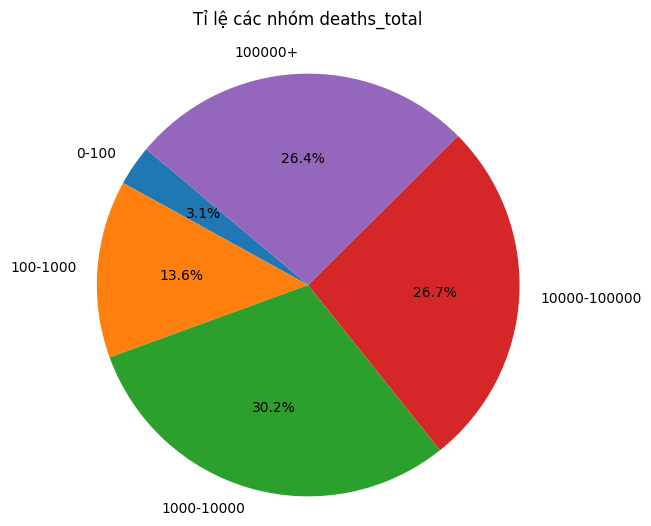

In [ ]:
# khai báo hư viện
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential
from keras.layers import Dense

# Đọc file CSV
df = pd.read_csv("/content/covid19.csv")
df

# Xử lý dữ liệu
df = df.dropna()
df
existing_columns = df.columns.tolist()
print(existing_columns)
columns_to_drop = ['index', 'country', 'continent', 'day', 'time']
columns_to_drop = [col for col in columns_to_drop if col in existing_columns]
df = df.drop(columns=columns_to_drop)
df
X = df.drop(columns=['deaths_total'])  # đầu vào
y = df['deaths_total']
sc = StandardScaler()
X = sc.fit_transform(X)

# Chia dữ liệu
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Xây dựng mô hình
model = Sequential()
model.add(Dense(64, input_dim=X.shape[1], activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='linear'))

# Compile model
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

# Huấn luyện
history = model.fit(x_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# Đánh giá
loss, mae = model.evaluate(x_test, y_test)
print(f"Test MAE: {mae:.2f}")
# Chia 'deaths_total' thành các nhóm
bins = [0, 100, 1000, 10000, 100000, np.inf]
labels = ['0-100', '100-1000', '1000-10000', '10000-100000', '100000+']
y_group = pd.cut(df['deaths_total'], bins=bins, labels=labels)

# Đếm số lượng mỗi nhóm
group_counts = y_group.value_counts().sort_index()

# Vẽ biểu đồ tròn
plt.figure(figsize=(6,6))
plt.pie(group_counts, labels=group_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Tỉ lệ các nhóm deaths_total\n')
plt.axis('equal')
plt.show()